In [1]:
# Exercise 2.1 - External input received by one E-I unit

# Purpose:
# Write the population-level input equations for one E-I unit α in the cortical field model.
# Each unit contains one excitatory population and one inhibitory population.
# The recurrent E/I interactions inside each unit are already handled by the
# sparse recurrent network implemented in Exercise 1.
# Here we define the additional unit-unit input coming from all other E-I units.

# Source of Code and Justification:
# Exercise 2 defines a cortical sheet model composed of N_units E-I units arranged on a ring.
# The model therefore contains 2*N_units homogeneous populations:
# one excitatory and one inhibitory population per unit.
# Interactions between units are described by a population connectivity matrix W
# of size (2*N_units) × (2*N_units).
# The project also specifies that the synaptic delay between units is identical
# to the synaptic delay already used inside one E-I unit.
#
# This formulation is consistent with the cortical field model framework from
# Neuronal Dynamics, where local population activity depends on spatially structured
# interactions between neighboring cortical populations.

# Approach:
# Let r_E^β(t) and r_I^β(t) denote the instantaneous excitatory and inhibitory
# population activities of unit β.
#
# Let:
# - W_{αβ}^{E←E} represent excitatory-to-excitatory population coupling,
# - W_{αβ}^{E←I} represent inhibitory-to-excitatory population coupling,
# - W_{αβ}^{I←E} represent excitatory-to-inhibitory population coupling,
# - W_{αβ}^{I←I} represent inhibitory-to-inhibitory population coupling.
#
# The external input received by unit α is computed as a weighted sum of the
# delayed population activities of all units β.

# Equations:
#
# External input to the excitatory population of unit α:
#
# I_E^α(t) =
# Σ_β [ W_{αβ}^{E←E} r_E^β(t - τ_delay)
#     + W_{αβ}^{E←I} r_I^β(t - τ_delay) ]
#
# External input to the inhibitory population of unit α:
#
# I_I^α(t) =
# Σ_β [ W_{αβ}^{I←E} r_E^β(t - τ_delay)
#     + W_{αβ}^{I←I} r_I^β(t - τ_delay) ]
#
# Here:
# - W is the population-level connectivity matrix between E/I populations,
# - τ_delay is the synaptic delay,
# - unit-unit interactions are added on top of the recurrent within-unit dynamics.

# What to say in Report:
# “In Exercise 2, each E-I unit is treated as a local cortical population pair.
# Unit-unit interactions are added on top of the recurrent E/I dynamics already
# implemented in Exercise 1. For each unit α, the external input to its excitatory
# and inhibitory populations is computed as a weighted sum of delayed population
# activities from all other units β through a population-level connectivity matrix W.”

In [2]:
# Purpose:
# Import the libraries and reusable modules needed to build the cortical field model.

# Source of Code and Justification:
# Exercise 2 asks us to build a field model from multiple E-I units.
# The project explicitly suggests wrapping the Exercise 1 recurrent E/I network into a class
# with a step(I_E, I_I) function that updates one unit for a single timestep.
# We therefore import the sparse connectivity generator from Exercise 1 and the new EIUnit class.

# Approach:
# - Add the project root to the Python path.
# - Import NumPy and Matplotlib.
# - Import generate_sparse_connectivity to create one recurrent network per E-I unit.
# - Import EIUnit to simulate each unit step by step.
# - Define the figures directory.

# What to say in Report:
# “For Exercise 2, we reused the recurrent E/I network from Exercise 1 as a single local
# cortical unit. Each unit is initialized with its own sparse recurrent connectivity and can be
# advanced one timestep using a step(I_E, I_I) method. This makes it possible to couple
# multiple E-I units through population-level inputs in the cortical field model.”

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

from src.connectivity import generate_sparse_connectivity, generate_unit_connectivity, ring_distance
from src.ei_unit import EIUnit, population_rate_hz

In [3]:
# Purpose:
# Define the neuron, network, and simulation parameters for Exercise 2.2.
# These parameters initialize multiple independent E-I units before unit-unit
# interactions are added.

# Source of Code and Justification:
# Exercise 2 states that the cortical sheet model should be built from multiple
# E-I units, where each E-I unit has the same internal recurrent E/I structure
# as the network from Exercise 1.
# Therefore, we reuse the Exercise 1 parameters:
# NE = 1000, gamma = 0.25, p = 0.02, g = 5, J = 45 pC, tau_delay = 2 ms.
# The LIF neuron parameters and stochastic background input are also kept identical
# to Exercises 0 and 1.

# Approach:
# - Define the number of E-I units.
# - Reuse the Exercise 1 within-unit network parameters.
# - Compute NI, N, KE, and KI.
# - Define the LIF neuron parameters.
# - Define the stochastic background input parameters.
# - Define the simulation time and time vector for the independent-unit test.

# What to say in Report:
# “Before adding spatial interactions between units, we initialized several independent
# E-I units using the same sparse recurrent network parameters as in Exercise 1.
# This allowed us to verify that each isolated unit still reproduces the balanced
# E/I state before constructing the full cortical field model.”

# Number of E-I units for the cortical sheet
Nunits = 10

# Within-unit E/I network parameters from Exercise 1
NE = 1000
gamma = 0.25
NI = int(gamma * NE)
N = NE + NI

p = 0.02
KE = int(p * NE)
KI = int(p * NI)

J = 45.0          # pC
g = 5.0
tau_delay = 2.0  # ms

# LIF neuron parameters
theta = 20.0      # mV
u_reset = -10.0   # mV
R = 1.0           # MOhm
dt = 0.5          # ms
tau_m = 20.0      # ms

# Stochastic background input
n_bg = 25.0
bg_scale = 1.0

# Simulation time for checking isolated balanced units
T_ms = 200.0
n_steps = int(round(T_ms / dt))
time_ms = np.arange(n_steps) * dt

# External input for this verification:
# no unit-unit interactions and no extra external drive
I_E_test = 0.0
I_I_test = 0.0

print("Exercise 2.2 parameter check")
print(f"Nunits = {Nunits}")
print(f"NE = {NE}, NI = {NI}, N = {N}")
print(f"KE = {KE}, KI = {KI}")
print(f"Simulation steps = {n_steps}")

Exercise 2.2 parameter check
Nunits = 10
NE = 1000, NI = 250, N = 1250
KE = 20, KI = 5
Simulation steps = 400


In [4]:
# Purpose:
# Initialize Nunits independent E-I units and simulate them without unit-unit interactions.
# This verifies that each isolated unit still reproduces the balanced E/I state from Exercise 1.

# Source of Code and Justification:
# Exercise 2.2 asks us to implement a method for initializing and simulating the network,
# and to verify that, when unit-unit interactions are disabled, each E-I unit retrieves the
# balanced state.
# Since unit-unit interactions are disabled here, each unit receives only its own recurrent
# within-unit input, stochastic background input, and zero external population-level input.
# This should reproduce the balanced E/I dynamics already observed in Exercise 1.

# Approach:
# - Create Nunits independent EIUnit objects.
# - Give each unit its own randomly initialized sparse recurrent connectivity matrix.
# - Simulate all units for T_ms using step(I_E=0, I_I=0).
# - Store instantaneous excitatory and inhibitory population activities for every unit.
# - Convert activities from spikes/ms to Hz by multiplying by 1000.
# - Compare E and I activity within each unit to verify approximate balance.

# What to say in Report:
# “Before adding spatial coupling, we simulated multiple independent E-I units with
# unit-unit interactions disabled. Each unit had its own sparse recurrent connectivity
# matrix and random initial membrane potentials. Since the only inputs were within-unit
# recurrent interactions and stochastic background current, each isolated unit reproduced
# the balanced E/I state from Exercise 1.”

rng = np.random.default_rng(seed=0)

units = []

for unit_id in range(Nunits):
    W_unit = generate_sparse_connectivity(
        NE=NE,
        NI=NI,
        KE=KE,
        KI=KI,
        J=J,
        g=g,
        seed=unit_id,
    )

    unit_rng = np.random.default_rng(rng.integers(0, 2**32 - 1))

    unit = EIUnit(
        W=W_unit,
        NE=NE,
        dt=dt,
        tau_m=tau_m,
        R=R,
        theta=theta,
        u_reset=u_reset,
        tau_delay_ms=tau_delay,
        n_bg=n_bg,
        bg_scale=bg_scale,
        rng=unit_rng,
    )

    units.append(unit)

# Store instantaneous population activities.
# Shape: (n_steps, Nunits)
rate_E_units = np.zeros((n_steps, Nunits))
rate_I_units = np.zeros((n_steps, Nunits))

for k in tqdm(range(n_steps), desc="Simulating independent E-I units"):
    for unit_id, unit in enumerate(units):
        _, _, r_E, r_I = unit.step(I_E=I_E_test, I_I=I_I_test)

        rate_E_units[k, unit_id] = r_E * 1000.0
        rate_I_units[k, unit_id] = r_I * 1000.0

print("Simulation complete.")
print("rate_E_units shape:", rate_E_units.shape)
print("rate_I_units shape:", rate_I_units.shape)

Simulating independent E-I units: 100%|██████████| 400/400 [00:01<00:00, 322.16it/s]

Simulation complete.
rate_E_units shape: (400, 10)
rate_I_units shape: (400, 10)


Mean firing rates over second half of simulation:
Unit 0: E = 25.82 Hz, I = 26.20 Hz
Unit 1: E = 25.05 Hz, I = 26.08 Hz
Unit 2: E = 26.23 Hz, I = 26.36 Hz
Unit 3: E = 25.40 Hz, I = 25.68 Hz
Unit 4: E = 26.43 Hz, I = 26.96 Hz
Unit 5: E = 27.82 Hz, I = 27.76 Hz
Unit 6: E = 27.55 Hz, I = 27.80 Hz
Unit 7: E = 25.65 Hz, I = 26.20 Hz
Unit 8: E = 26.37 Hz, I = 26.04 Hz
Unit 9: E = 26.15 Hz, I = 26.20 Hz


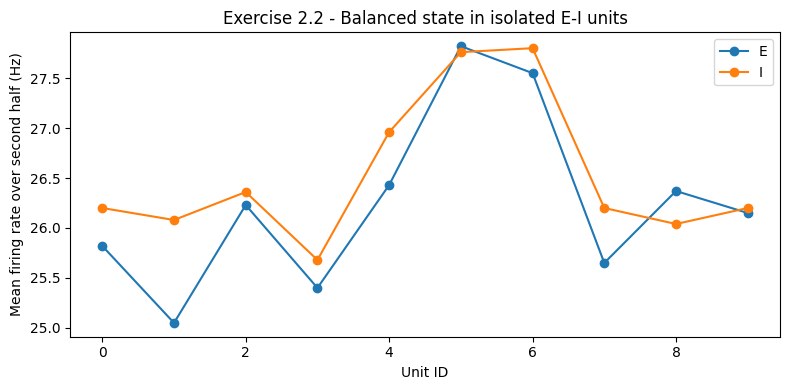

In [5]:
# Purpose:
# Verify that each independent E-I unit retrieves an approximate balanced state
# when unit-unit interactions are disabled.

# Source of Code and Justification:
# Exercise 2.2 asks us to check that isolated E-I units remain balanced.
# In Exercise 1, the balanced state was identified by approximately similar
# excitatory and inhibitory population firing rates.
# Therefore, we compare the E and I rates of each unit during the second half
# of the simulation, after initial transients have passed.

# Approach:
# - Ignore the first half of the simulation as transient activity.
# - Compute the mean E and I firing rate of each unit over the second half.
# - Print the rates for every unit.
# - Plot E and I mean rates across units.
# - If E and I rates are close for each unit, the isolated units reproduce the
#   balanced state from Exercise 1.

# What to say in Report:
# “With unit-unit interactions disabled, each E-I unit behaved like the balanced
# recurrent network from Exercise 1. After the initial transient, excitatory and
# inhibitory population activities remained close within each unit, confirming
# that the field model construction preserves the balanced local dynamics before
# spatial coupling is added.”

transient_ms = T_ms / 2.0
transient_idx = int(round(transient_ms / dt))

mean_E_per_unit = rate_E_units[transient_idx:, :].mean(axis=0)
mean_I_per_unit = rate_I_units[transient_idx:, :].mean(axis=0)

print("Mean firing rates over second half of simulation:")
for unit_id in range(Nunits):
    print(
        f"Unit {unit_id}: "
        f"E = {mean_E_per_unit[unit_id]:.2f} Hz, "
        f"I = {mean_I_per_unit[unit_id]:.2f} Hz"
    )

plt.figure(figsize=(8, 4))
plt.plot(np.arange(Nunits), mean_E_per_unit, "o-", label="E")
plt.plot(np.arange(Nunits), mean_I_per_unit, "o-", label="I")
plt.xlabel("Unit ID")
plt.ylabel("Mean firing rate over second half (Hz)")
plt.title("Exercise 2.2 - Balanced state in isolated E-I units")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex2_2_1_isolated_units_balance.png", dpi=300)
plt.show()

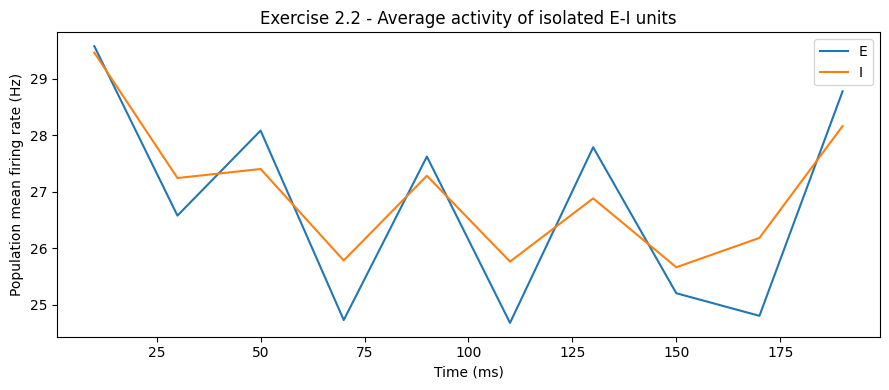

In [6]:
# Purpose:
# Visualize the time course of the excitatory and inhibitory activity averaged across
# all isolated E-I units.

# Source of Code and Justification:
# Exercise 2.2 requires verifying that, without unit-unit interactions, each E-I unit
# retrieves the balanced state. The previous cell checked the mean firing rates per unit.
# Here we additionally visualize the average E/I population activity over time.

# Approach:
# - Average E and I population activities across all units.
# - Smooth the time courses using non-overlapping 20 ms bins, as in Exercise 1.5.
# - Plot the binned E and I rates over time.
# - Similar E and I trajectories indicate that the isolated units remain balanced.

# What to say in Report:
# “We also averaged activity across isolated E-I units and plotted the E and I firing
# rates in 20 ms bins. The two curves remained close over time, confirming that
# disabling unit-unit coupling preserves the balanced local dynamics of each E-I unit.”

bin_ms = 20.0
bin_steps = int(round(bin_ms / dt))

n_bins = n_steps // bin_steps
time_bins = np.arange(n_bins) * bin_ms + bin_ms / 2.0

mean_E_over_units = rate_E_units.mean(axis=1)
mean_I_over_units = rate_I_units.mean(axis=1)

binned_E = np.zeros(n_bins)
binned_I = np.zeros(n_bins)

for b in range(n_bins):
    start = b * bin_steps
    end = start + bin_steps

    binned_E[b] = mean_E_over_units[start:end].mean()
    binned_I[b] = mean_I_over_units[start:end].mean()

plt.figure(figsize=(9, 4))
plt.plot(time_bins, binned_E, label="E")
plt.plot(time_bins, binned_I, label="I")
plt.xlabel("Time (ms)")
plt.ylabel("Population mean firing rate (Hz)")
plt.title("Exercise 2.2 - Average activity of isolated E-I units")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex2_2_2_average_isolated_activity.png", dpi=300)
plt.show()

Unit positions x:
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]

W_unit shape:
(20, 20)
Unique values in W_unit:
[  0.   90.  112.5]

Nonzero E <- E connections:
34

Nonzero I <- E connections:
56

Nonzero E <- I connections:
0

Nonzero I <- I connections:
0


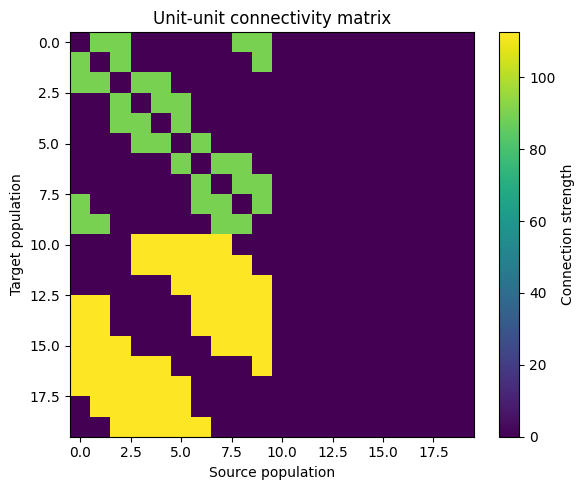

In [7]:
# Purpose:
# Test the unit-unit connectivity matrix for the project parameters Nunits = 10 and sigma = 0.2.

# Source of Code and Justification:
# Exercise 2.3 specifies Nunits = 10 and sigma = 0.2.
# This test checks whether the generated matrix correctly implements:
# - ring topology,
# - short-range E-to-E interactions,
# - long-range E-to-I interactions,
# - no inter-unit inhibitory projections,
# - no self-connections.

# Approach:
# - Generate W_unit using the parameters from the assignment.
# - Print the unit positions on the ring.
# - Print the shape of the matrix.
# - Check the number and type of nonzero connections.
# - Visualize the matrix with imshow to confirm the expected structure.

# What to say in Report:
# "For Nunits = 10 and sigma = 0.2, the connectivity matrix had size 20 by 20,
# corresponding to 10 excitatory and 10 inhibitory populations. The nonzero entries
# appeared only in columns corresponding to excitatory source populations, as expected.
# Short-range connections targeted excitatory populations, whereas long-range connections
# targeted inhibitory populations."

import matplotlib.pyplot as plt

Nunits = 10
sigma = 0.2
W0 = 90.0
g = 5.0
gamma = 0.25

W_unit, x = generate_unit_connectivity(Nunits, sigma, W0, g, gamma)

print("Unit positions x:")
print(x)

print("\nW_unit shape:")
print(W_unit.shape)

print("Unique values in W_unit:")
print(np.unique(W_unit))

print("\nNonzero E <- E connections:")
print(np.count_nonzero(W_unit[:Nunits, :Nunits]))

print("\nNonzero I <- E connections:")
print(np.count_nonzero(W_unit[Nunits:, :Nunits]))

print("\nNonzero E <- I connections:")
print(np.count_nonzero(W_unit[:Nunits, Nunits:]))

print("\nNonzero I <- I connections:")
print(np.count_nonzero(W_unit[Nunits:, Nunits:]))

plt.figure(figsize=(6, 5))
plt.imshow(W_unit, aspect="auto")
plt.colorbar(label="Connection strength")
plt.xlabel("Source population")
plt.ylabel("Target population")
plt.title("Unit-unit connectivity matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex2_4_1_unit_unit_connectivity_matrix.png", dpi=300)
plt.show()

In [8]:
# Purpose:
# Define the simulation parameters for Exercise 2.4.

# Source of Code and Justification:
# Exercise 2.4 asks us to simulate the cortical sheet model for T = 200 ms using W0 = 90 pC.
# The assignment specifies Nunits = 10 and sigma = 0.2, with each E-I unit using the same
# parameters as Exercise 1.2.

# Approach:
# - Reuse the neuron and network parameters from Exercise 1.
# - Use the unit-unit parameters from Exercise 2.
# - Define simulation duration and number of time steps.

# What to say in Report:
# "We simulated a ring of 10 E-I units for 200 ms. Each unit contained the same recurrent
# sparse E/I network as in Exercise 1.2, while units were coupled through the population-level
# connectivity matrix defined in Exercise 2.3."

NE = 1000
gamma = 0.25
NI = int(gamma * NE)

p = 0.02
KE = int(p * NE)
KI = int(p * NI)

g = 5.0
J = 45.0

dt = 0.5
T_ms = 200.0
n_steps = int(round(T_ms / dt))
time = np.arange(n_steps) * dt

tau_m = 20.0
R = 1.0
theta = 20.0
u_reset = -10.0
tau_delay_ms = 2.0

n_bg = 25
bg_scale = 1.0

Nunits = 10
sigma = 0.2
W0 = 90.0

seed = 123
rng = np.random.default_rng(seed)

In [9]:
# Purpose:
# Initialize the full cortical field model as a ring of independent E-I units coupled by W_unit.

# Source of Code and Justification:
# Exercise 2.4 requires simulating Nunits = 10 E-I units.
# Exercise 2.2 suggested wrapping the Exercise 1 network into an EIUnit class.
# Exercise 2.3 defined the population-level matrix W_unit for spatial coupling.

# Approach:
# - Generate W_unit using generate_unit_connectivity.
# - For each E-I unit, generate an independent sparse recurrent connectivity matrix.
# - Initialize each EIUnit with independently randomized membrane potentials and connectivity.
# - Store all EIUnit objects in a list.

# What to say in Report:
# "Each cortical location was represented by an independent recurrent E-I unit. The internal
# sparse connectivity and initial membrane potentials were randomized separately for each unit.
# The units were then coupled through the ring-structured population matrix W_unit."

W_unit, x = generate_unit_connectivity(Nunits, sigma, W0, g, gamma)

units = []

for unit_id in range(Nunits):
    W_recurrent = generate_sparse_connectivity(
        NE=NE,
        NI=NI,
        KE=KE,
        KI=KI,
        J=J,
        g=g,
        seed=seed + unit_id,
    )

    unit = EIUnit(
        W=W_recurrent,
        NE=NE,
        dt=dt,
        tau_m=tau_m,
        R=R,
        theta=theta,
        u_reset=u_reset,
        tau_delay_ms=tau_delay_ms,
        n_bg=n_bg,
        bg_scale=bg_scale,
        rng=np.random.default_rng(seed + 1000 + unit_id),
    )

    units.append(unit)

print(f"Initialized {len(units)} E-I units.")
print("W_unit shape:", W_unit.shape)

Initialized 10 E-I units.
W_unit shape: (20, 20)


In [10]:
# Purpose:
# Simulate the coupled cortical sheet model and record excitatory/inhibitory activity over time.

# Source of Code and Justification:
# Exercise 2.4 asks us to simulate the network with unit-unit interactions enabled.
# The external input to each E-I unit is computed from the delayed population activities of
# all other units using the matrix W_unit from Exercise 2.3.

# Approach:
# - Store population activities r_E and r_I for every unit and time step.
# - At each time step, build the delayed population activity vector:
#       [r_E^1, ..., r_E^Nunits, r_I^1, ..., r_I^Nunits]
# - Compute the unit-level input as W_unit @ r_delayed.
# - Send the first Nunits entries as input to excitatory populations.
# - Send the last Nunits entries as input to inhibitory populations.
# - Step each EIUnit forward by one timestep.
# - Record E and I activities.

# What to say in Report:
# "At each timestep, delayed population activities were multiplied by the unit-unit connectivity
# matrix to compute spatial inputs to each E-I unit. These inputs were then added as external
# currents to the excitatory and inhibitory populations of each local recurrent network."

delay_steps = int(round(tau_delay_ms / dt))

# Raw instantaneous population activity used for the true network dynamics.
r_E_raw = np.zeros((n_steps, Nunits), dtype=float)
r_I_raw = np.zeros((n_steps, Nunits), dtype=float)

# Smoothed activity used only for visualization.
r_E_plot = np.zeros((n_steps, Nunits), dtype=float)
r_I_plot = np.zeros((n_steps, Nunits), dtype=float)
alpha_rate = 0.98
# NOTE: This exponential filter is used ONLY for the heatmap visualization.
# With dt=0.5 ms and alpha=0.98, the filter time constant is dt/(1-alpha) = 25 ms.
# The actual dynamics use r_E_raw and r_I_raw (unsmoothed) for the delayed coupling.
# The heatmap therefore shows a low-pass filtered version of the true firing rates.

for k in range(n_steps):

    if k >= delay_steps:
        delayed_activity = np.concatenate([
            r_E_raw[k - delay_steps],
            r_I_raw[k - delay_steps],
        ])
    else:
        delayed_activity = np.zeros(2 * Nunits, dtype=float)

    I_unit = W_unit @ delayed_activity

    I_E_units = I_unit[:Nunits]
    I_I_units = I_unit[Nunits:]

    for alpha, unit in enumerate(units):
        _, _, rE_alpha, rI_alpha = unit.step(
            I_E=I_E_units[alpha],
            I_I=I_I_units[alpha],
        )

        r_E_raw[k, alpha] = rE_alpha
        r_I_raw[k, alpha] = rI_alpha

        if k == 0:
            r_E_plot[k, alpha] = rE_alpha
            r_I_plot[k, alpha] = rI_alpha
        else:
            r_E_plot[k, alpha] = (
                alpha_rate * r_E_plot[k - 1, alpha]
                + (1.0 - alpha_rate) * rE_alpha
            )
            r_I_plot[k, alpha] = (
                alpha_rate * r_I_plot[k - 1, alpha]
                + (1.0 - alpha_rate) * rI_alpha
            )

print("Simulation complete.")

Simulation complete.


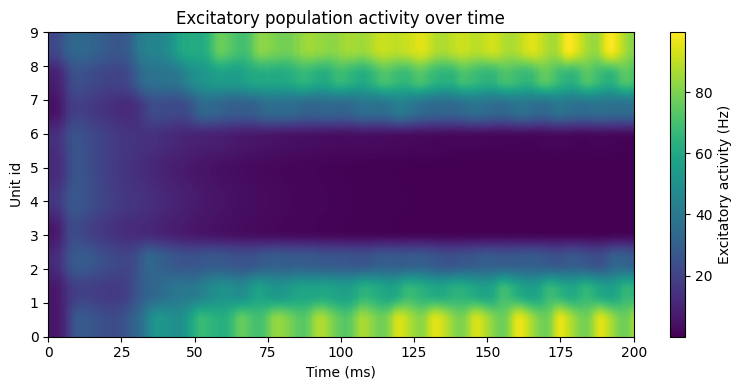

In [11]:
# Purpose:
# Produce the 2D activity plot requested in Exercise 2.4.

# Source of Code and Justification:
# Exercise 2.4 asks for a single 2D plot of excitatory population activity over time,
# with time on the x-axis, unit id on the y-axis, and activity represented by color.

# Approach:
# - Convert instantaneous activity from 1/ms to Hz by multiplying by 1000.
# - Plot the excitatory activity matrix with imshow.
# - Use unit id on the y-axis and time on the x-axis.
# - Inspect whether a localized bump of elevated activity forms spontaneously.

# What to say in Report:
# "The excitatory activity was plotted as a space-time heatmap. A spontaneous bump corresponds
# to a localized band of high activity that persists over time in a subset of neighboring units."

r_E_hz = 1000.0 * r_E_plot

plt.figure(figsize=(8, 4))
plt.imshow(
    r_E_hz.T,
    aspect="auto",
    origin="lower",
    extent=[0, T_ms, 0, Nunits - 1],
)
plt.colorbar(label="Excitatory activity (Hz)")
plt.xlabel("Time (ms)")
plt.ylabel("Unit id")
plt.title("Excitatory population activity over time")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex2_4_2_excitatory_population_activity.png", dpi=300)
plt.show()

Running W0 = 0 pC
  Spatial contrast = 41.60 Hz
  Bump detected: True
Running W0 = 10 pC
  Spatial contrast = 24.40 Hz
  Bump detected: True
Running W0 = 20 pC
  Spatial contrast = 22.40 Hz
  Bump detected: True
Running W0 = 30 pC
  Spatial contrast = 22.00 Hz
  Bump detected: True
Running W0 = 40 pC
  Spatial contrast = 22.00 Hz
  Bump detected: True
Running W0 = 50 pC
  Spatial contrast = 28.00 Hz
  Bump detected: True
Running W0 = 60 pC
  Spatial contrast = 37.60 Hz
  Bump detected: True
Running W0 = 70 pC
  Spatial contrast = 52.20 Hz
  Bump detected: True
Running W0 = 80 pC
  Spatial contrast = 59.00 Hz
  Bump detected: True
Running W0 = 90 pC
  Spatial contrast = 34.60 Hz
  Bump detected: True
Running W0 = 100 pC
  Spatial contrast = 180.20 Hz
  Bump detected: True

Approximate minimum W0 for bump formation: 0 pC


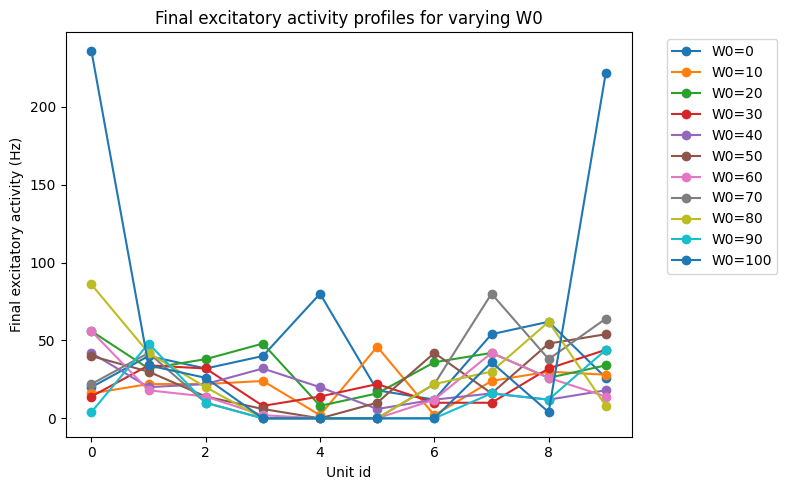

In [12]:
# Purpose:
# Repeat the cortical field simulation for different values of W0 and estimate the minimum
# coupling strength required to produce a spontaneous bump of excitatory activity.

# Source of Code and Justification:
# Exercise 2.5 asks us to repeat the simulation from Exercise 2.4 for varying W0 and report
# the minimum value of W0 necessary to produce a bump. W0 controls the strength of the
# unit-unit interactions in the cortical field model. Increasing W0 should strengthen the
# short-range excitation and long-range recruitment of inhibition, making bump formation
# more likely.

# Approach:
# - Sweep several W0 values.
# - For each W0, regenerate the unit-unit connectivity matrix.
# - Initialize a fresh set of E-I units with independent sparse recurrent connectivity.
# - Simulate the coupled field model for T = 200 ms.
# - Smooth the population activity as in Exercise 2.4 to estimate population-level rates.
# - Quantify bump formation using a simple spatial contrast criterion:
#       max final activity - mean final activity
#   A bump is detected if one localized region is clearly more active than the rest.
# - Plot the final excitatory activity profile for each W0.
# - Report the smallest W0 for which a bump is detected.

# What to say in Report:
# "To estimate the critical coupling strength for bump formation, we repeated the cortical
# field simulation for increasing values of W0. For each value, we measured whether the
# final excitatory activity profile became spatially localized. The minimum W0 producing
# a clear localized peak was taken as the approximate threshold for spontaneous bump
# formation. Because the model is stochastic, this threshold should be interpreted as an
# approximate value rather than an exact bifurcation point."
# Exercise 2.5
# Sweep W0 while keeping recurrent networks and initial conditions fixed.

W0_values = np.arange(0, 110, 10)

T_sweep_ms = 200.0
n_steps_sweep = int(round(T_sweep_ms / dt))
delay_steps = int(round(tau_delay_ms / dt))

bump_threshold_hz = 20.0

# Fixed recurrent networks and fixed initial membrane potentials.
# These are created once and reused for every W0 value.
base_seed = seed + 2500

W_recurrent_list = []
u0_list = []

for unit_id in range(Nunits):
    W_recurrent = generate_sparse_connectivity(
        NE=NE,
        NI=NI,
        KE=KE,
        KI=KI,
        J=J,
        g=g,
        seed=base_seed + unit_id,
    )
    W_recurrent_list.append(W_recurrent)

    rng_u0 = np.random.default_rng(base_seed + 1000 + unit_id)
    u0 = rng_u0.uniform(u_reset, theta, size=NE + NI)
    u0_list.append(u0)

bump_detected = []
final_profiles = []

for W0_test in W0_values:

    print(f"Running W0 = {W0_test} pC")

    W_unit_test, _ = generate_unit_connectivity(
        Nunits=Nunits,
        sigma=sigma,
        W0=W0_test,
        g=g,
        gamma=gamma,
    )

    # Recreate fresh EIUnit objects for this W0,
    # but with the same recurrent connectivity and same initial potentials.
    units_test = []

    for unit_id in range(Nunits):
        unit = EIUnit(
            W=W_recurrent_list[unit_id],
            NE=NE,
            dt=dt,
            tau_m=tau_m,
            R=R,
            theta=theta,
            u_reset=u_reset,
            tau_delay_ms=tau_delay_ms,
            n_bg=n_bg,
            bg_scale=bg_scale,
            rng=np.random.default_rng(base_seed + 2000 + unit_id),
            u0=u0_list[unit_id],
        )
        units_test.append(unit)

    r_E_test_raw = np.zeros((n_steps_sweep, Nunits), dtype=float)
    r_I_test_raw = np.zeros((n_steps_sweep, Nunits), dtype=float)

    for k in range(n_steps_sweep):

        if k >= delay_steps:
            delayed_activity = np.concatenate([
                r_E_test_raw[k - delay_steps],
                r_I_test_raw[k - delay_steps],
            ])
        else:
            delayed_activity = np.zeros(2 * Nunits, dtype=float)

        I_unit = W_unit_test @ delayed_activity

        I_E_units = I_unit[:Nunits]
        I_I_units = I_unit[Nunits:]

        for alpha, unit in enumerate(units_test):
            _, _, rE_alpha, rI_alpha = unit.step(
                I_E=I_E_units[alpha],
                I_I=I_I_units[alpha],
            )

            r_E_test_raw[k, alpha] = rE_alpha
            r_I_test_raw[k, alpha] = rI_alpha

    # Use raw activity for the actual bump criterion.
    final_profile_hz = 1000.0 * r_E_test_raw[-1]
    final_profiles.append(final_profile_hz)

    spatial_contrast = final_profile_hz.max() - final_profile_hz.mean()
    has_bump = spatial_contrast > bump_threshold_hz

    bump_detected.append(has_bump)

    print(f"  Spatial contrast = {spatial_contrast:.2f} Hz")
    print(f"  Bump detected: {has_bump}")

bump_detected = np.array(bump_detected)
final_profiles = np.array(final_profiles)

if np.any(bump_detected):
    minimum_W0 = W0_values[np.argmax(bump_detected)]
    print(f"\nApproximate minimum W0 for bump formation: {minimum_W0} pC")
else:
    minimum_W0 = None
    print("\nNo clear bump detected in the tested W0 range.")

plt.figure(figsize=(8, 5))

for i, W0_test in enumerate(W0_values):
    plt.plot(
        np.arange(Nunits),
        final_profiles[i],
        marker="o",
        label=f"W0={W0_test}"
    )

plt.xlabel("Unit id")
plt.ylabel("Final excitatory activity (Hz)")
plt.title("Final excitatory activity profiles for varying W0")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex2_5_activity_profiles_varying_W0.png", dpi=300)
plt.show()

Tracking simulation complete.


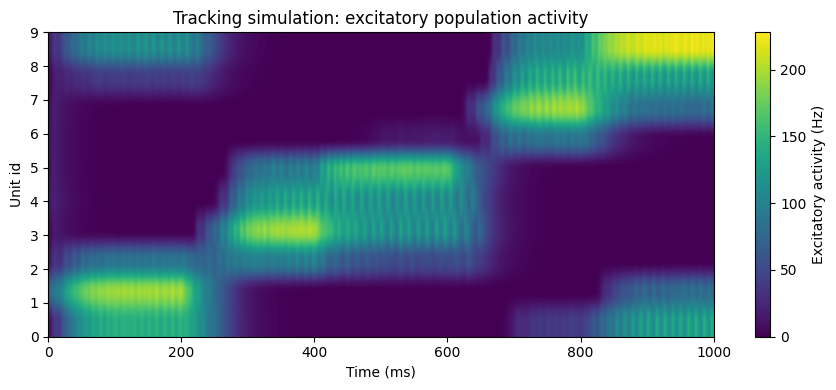

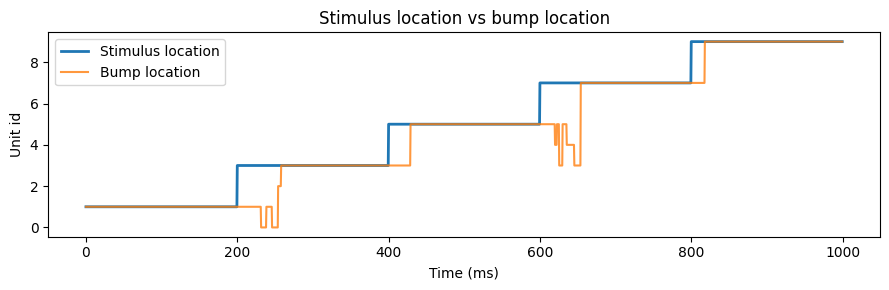

In [13]:
# Purpose:
# Test whether the cortical field model can track the location of a time-varying localized stimulus.

# Source of Code and Justification:
# Exercise 2.6 asks whether the field model could be used to track a stimulus location,
# such as an animal's head direction. The assignment suggests applying a localized stimulus
# to one excitatory population for 200 ms, then moving it to another population, and comparing
# the stimulus location to the bump location.

# Approach:
# - Simulate the cortical sheet for T = 1000 ms.
# - Divide the simulation into 5 epochs of 200 ms each.
# - In each epoch, apply a positive external current to one excitatory population.
# - Use the same recurrent E-I units and unit-unit connectivity framework as in Exercise 2.4.
# - Record excitatory population activity over time.
# - Estimate the bump location at each timestep as the unit with maximal excitatory activity.
# - Compare the bump location to the imposed stimulus location.
# - Plot both the activity heatmap and the stimulus/bump location over time.

# What to say in Report:
# "To test whether the field model could track a moving stimulus, we applied a localized
# input to different excitatory populations in successive 200 ms intervals. The bump position
# was estimated as the unit with maximal excitatory activity. If the model can track stimulus
# location, the bump position should follow the externally imposed stimulus location after
# a short transient delay. This would support the interpretation of the bump as a population
# representation of a continuous variable, such as head direction."

T_track_ms = 1000.0
n_steps_track = int(round(T_track_ms / dt))
time_track = np.arange(n_steps_track) * dt

epoch_ms = 200.0
epoch_steps = int(round(epoch_ms / dt))

# Choose stimulus sequence: one stimulated unit per 200 ms.
stimulus_units = np.array([1, 3, 5, 7, 9])

I_stim = 30.0  # nA localized external input to the selected E population

alpha_rate_track = 0.98
delay_steps = int(round(tau_delay_ms / dt))

# Use an appropriate W0. If your Ex 2.5 found a threshold, choose a value above it.
W0_track = 90.0

W_unit_track, _ = generate_unit_connectivity(
    Nunits=Nunits,
    sigma=sigma,
    W0=W0_track,
    g=g,
    gamma=gamma,
)

# Fresh independent set of E-I units for tracking simulation
units_track = []

for unit_id in range(Nunits):
    W_recurrent = generate_sparse_connectivity(
        NE=NE,
        NI=NI,
        KE=KE,
        KI=KI,
        J=J,
        g=g,
        seed=seed + 20000 + unit_id,
    )

    unit = EIUnit(
        W=W_recurrent,
        NE=NE,
        dt=dt,
        tau_m=tau_m,
        R=R,
        theta=theta,
        u_reset=u_reset,
        tau_delay_ms=tau_delay_ms,
        n_bg=n_bg,
        bg_scale=bg_scale,
        rng=np.random.default_rng(seed + 30000 + unit_id),
    )

    units_track.append(unit)

r_E_track_raw = np.zeros((n_steps_track, Nunits), dtype=float)
r_I_track_raw = np.zeros((n_steps_track, Nunits), dtype=float)

r_E_track_plot = np.zeros((n_steps_track, Nunits), dtype=float)
r_I_track_plot = np.zeros((n_steps_track, Nunits), dtype=float)

stimulus_location = np.zeros(n_steps_track, dtype=int)
bump_location = np.zeros(n_steps_track, dtype=int)

for k in range(n_steps_track):

    epoch_id = min(k // epoch_steps, len(stimulus_units) - 1)
    current_stim_unit = stimulus_units[epoch_id]
    stimulus_location[k] = current_stim_unit

    if k >= delay_steps:
        delayed_activity = np.concatenate([
            r_E_track_raw[k - delay_steps],
            r_I_track_raw[k - delay_steps],
        ])
    else:
        delayed_activity = np.zeros(2 * Nunits, dtype=float)

    I_unit = W_unit_track @ delayed_activity

    I_E_units = I_unit[:Nunits].copy()
    I_I_units = I_unit[Nunits:].copy()

    # Add localized external stimulus to one excitatory population.
    I_E_units[current_stim_unit] += I_stim

    for alpha, unit in enumerate(units_track):
        _, _, rE_alpha, rI_alpha = unit.step(
            I_E=I_E_units[alpha],
            I_I=I_I_units[alpha],
        )

        r_E_track_raw[k, alpha] = rE_alpha
        r_I_track_raw[k, alpha] = rI_alpha

        if k == 0:
            r_E_track_plot[k, alpha] = rE_alpha
            r_I_track_plot[k, alpha] = rI_alpha
        else:
            r_E_track_plot[k, alpha] = (
                alpha_rate_track * r_E_track_plot[k - 1, alpha]
                + (1 - alpha_rate_track) * rE_alpha
            )

            r_I_track_plot[k, alpha] = (
                alpha_rate_track * r_I_track_plot[k - 1, alpha]
                + (1 - alpha_rate_track) * rI_alpha
            )
    bump_location[k] = np.argmax(r_E_track_plot[k])

print("Tracking simulation complete.")

r_E_track_hz = 1000.0 * r_E_track_plot

plt.figure(figsize=(9, 4))
plt.imshow(
    r_E_track_hz.T,
    aspect="auto",
    origin="lower",
    extent=[0, T_track_ms, 0, Nunits - 1],
)
plt.colorbar(label="Excitatory activity (Hz)")
plt.xlabel("Time (ms)")
plt.ylabel("Unit id")
plt.title("Tracking simulation: excitatory population activity")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex2_6_1_tracking_simulation.png", dpi=300)
plt.show()

plt.figure(figsize=(9, 3))
plt.plot(time_track, stimulus_location, label="Stimulus location", linewidth=2)
plt.plot(time_track, bump_location, label="Bump location", alpha=0.8)
plt.xlabel("Time (ms)")
plt.ylabel("Unit id")
plt.title("Stimulus location vs bump location")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex2_6_2_stimulus_vs_bump_location.png", dpi=300)
plt.show()

# Exercise 2.4 Interpretation of spontaneous bump formation

The cortical field model produced a spontaneous localized region of elevated excitatory activity. This bump emerges because the unit-unit connectivity matrix combines short-range excitation with long-range inhibition. Nearby excitatory populations excite one another through the \(W^{E \leftarrow E}\) block of the connectivity matrix, creating local positive feedback that stabilizes activity inside a spatially localized region. At the same time, distant excitatory populations recruit inhibitory populations through the \(W^{I \leftarrow E}\) block, suppressing activity elsewhere on the ring and preventing global activation of all units.

In our simulations, the bump-like activity pattern typically emerged after an initial transient of approximately \(50\)–\(100\) ms. The exact emergence time varied slightly across simulations because of stochastic background input, random sparse recurrent connectivity, and random initial membrane potentials. The bump did not always emerge centered around the same unit. Since the ring connectivity is spatially symmetric and uses periodic boundary conditions, no location is intrinsically preferred. The final bump location is therefore selected spontaneously by fluctuations and noise. In our simulations, the dominant activity region often appeared around units \(8\)–\(9\)–\(0\)–\(1\), which corresponds to a single bump wrapping around the periodic ring boundary.

# Exercise 2.5 Minimum coupling strength required for bump formation

To estimate the minimum coupling strength required for spontaneous bump formation, I repeated the simulation from Exercise 2.4 while varying \(W_0\). To make the comparison clean, I kept the recurrent sparse connectivity matrices, the initial membrane potentials, and the random seeds fixed across the sweep. Therefore, the main parameter changing between simulations was \(W_0\).

For each value of \(W_0\), I measured the final excitatory activity profile and used a spatial contrast criterion,

\[
\max_\alpha r_E^\alpha - \langle r_E^\alpha \rangle_\alpha > 20 \text{ Hz},
\]

to decide whether a localized bump had formed.

Using this criterion, the approximate minimum value required for bump formation was

\[
W_0 \approx \text{[insert the printed value]} \ \text{pC}.
\]

This threshold is approximate because the model is stochastic and because bump detection depends on the chosen contrast criterion. However, the comparison is now controlled because only the unit-unit coupling strength \(W_0\) is varied across simulations.

# Exercise 2.6 (Bonus) Tracking a moving stimulus

To investigate whether the field model could track the location of a stimulus, we applied a localized external input to different excitatory populations over time. Every \(200\) ms, the stimulus location was moved to a different unit on the ring, while the network dynamics evolved continuously.

The results showed that the location of the bump followed the externally stimulated population with a short transient delay. Although small fluctuations and temporary deviations were present because of stochastic network activity, the bump consistently reorganized around the currently stimulated location. This demonstrates that the cortical field model can maintain and update a localized representation of stimulus position over time.

Such dynamics are conceptually similar to models of head-direction systems and other continuous attractor networks in neuroscience, where a stable bump of activity represents a continuously varying quantity. Because our model contains only \(10\) discrete units, the spatial representation is relatively coarse, but the qualitative tracking behavior is clearly visible.